# Macro co-movement
This notebook explores relationships between economic freedom and macro
indicators using scatterplots and correlation summaries.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import CLEAN_DIR, OUTPUT_DIR, QUINQUENNIAL_YEARS
from src.viz_style import savefig, set_style

In [2]:
set_style()
panel_path = CLEAN_DIR / "panel_quinquennial_atlas.parquet"
if not panel_path.exists():
    raise FileNotFoundError("Missing atlas panel. Run 03_build_quinquennial_panel first.")

panel = pd.read_parquet(panel_path)

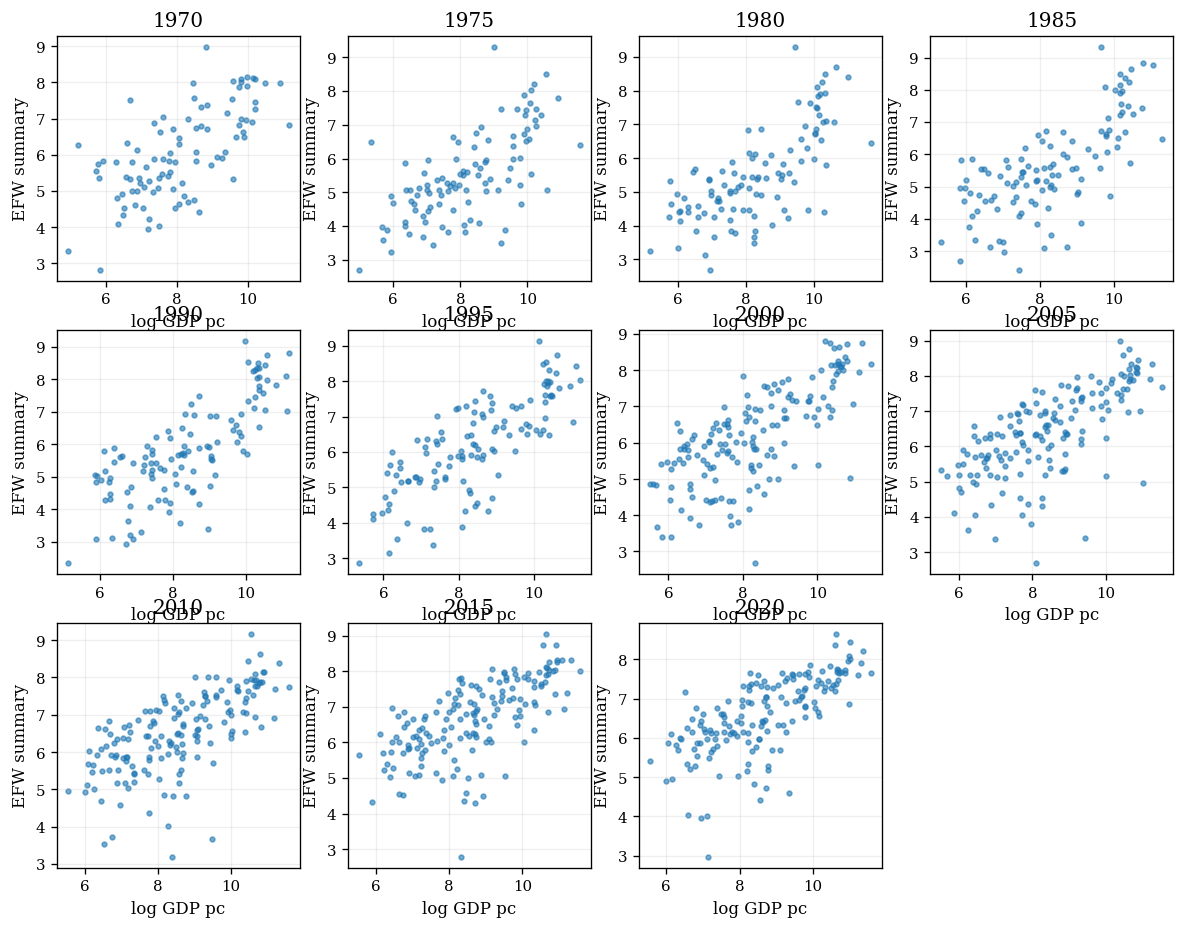

In [3]:
if "efw_summary" in panel.columns and "log_gdp_pc_const" in panel.columns:
    years = QUINQUENNIAL_YEARS
    cols = 4
    rows = (len(years) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows), sharex=False, sharey=False)
    axes = axes.flatten()
    for idx, year in enumerate(years):
        ax = axes[idx]
        subset = panel[panel["year"] == year]
        ax.scatter(subset["log_gdp_pc_const"], subset["efw_summary"], s=8, alpha=0.6)
        ax.set_title(str(year))
        ax.set_xlabel("log GDP pc")
        ax.set_ylabel("EFW summary")
    for ax in axes[len(years):]:
        ax.axis("off")
    display(fig)
    savefig(fig, OUTPUT_DIR / "figures" / "comovement" / "scatter_levels")
    plt.close(fig)

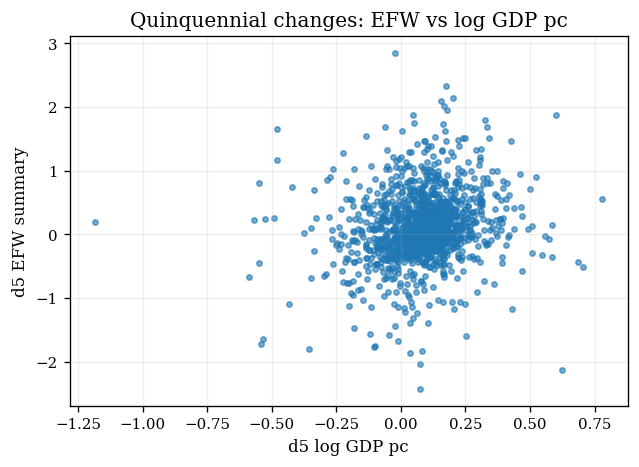

In [4]:
if "d5_efw_summary" in panel.columns and "d5_log_gdp_pc_const" in panel.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    subset = panel.dropna(subset=["d5_efw_summary", "d5_log_gdp_pc_const"])
    ax.scatter(subset["d5_log_gdp_pc_const"], subset["d5_efw_summary"], s=10, alpha=0.6)
    ax.set_title("Quinquennial changes: EFW vs log GDP pc")
    ax.set_xlabel("d5 log GDP pc")
    ax.set_ylabel("d5 EFW summary")
    display(fig)
    savefig(fig, OUTPUT_DIR / "figures" / "comovement" / "scatter_changes")
    plt.close(fig)

,efw_summary,log_gdp_pc_const,inflation_cpi_ann_pct,trade_open_gdp,gov_cons_gdp
efw_summary,1.00,0.69,-0.10,0.35,0.13
log_gdp_pc_const,0.69,1.00,-0.03,0.33,0.24
inflation_cpi_ann_pct,-0.10,-0.03,1.00,-0.04,-0.04
trade_open_gdp,0.35,0.33,-0.04,1.00,0.16
gov_cons_gdp,0.13,0.24,-0.04,0.16,1.00


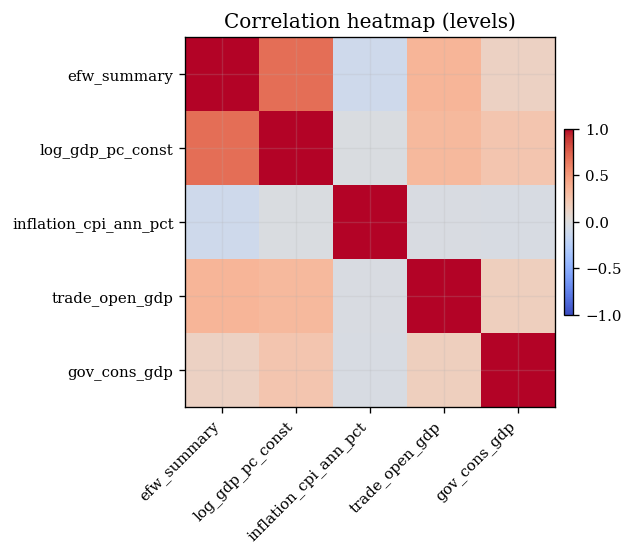

In [5]:
vars_for_corr = [
    col
    for col in [
        "efw_summary",
        "log_gdp_pc_const",
        "inflation_cpi_ann_pct",
        "trade_open_gdp",
        "gov_cons_gdp",
    ]
    if col in panel.columns
]

if vars_for_corr:
    corr = panel[vars_for_corr].corr()
    display(corr.style.format(precision=2).set_caption("Correlation matrix (levels)"))
    fig, ax = plt.subplots(figsize=(5, 4))
    img = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(vars_for_corr)))
    ax.set_xticklabels(vars_for_corr, rotation=45, ha="right")
    ax.set_yticks(range(len(vars_for_corr)))
    ax.set_yticklabels(vars_for_corr)
    fig.colorbar(img, ax=ax, fraction=0.02, pad=0.02)
    ax.set_title("Correlation heatmap (levels)")
    display(fig)
    savefig(fig, OUTPUT_DIR / "figures" / "comovement" / "correlation_heatmap_levels")
    plt.close(fig)

In [6]:
if vars_for_corr:
    between = panel.groupby("iso3c")[vars_for_corr].mean().corr()
    within = panel[vars_for_corr].subtract(panel.groupby("iso3c")[vars_for_corr].transform("mean")).corr()

    out_rows = []
    for name, matrix in [("between", between), ("within", within)]:
        melted = matrix.reset_index().melt(id_vars="index", var_name="var2", value_name="corr")
        melted = melted.rename(columns={"index": "var1"})
        melted["type"] = name
        out_rows.append(melted)
    out = pd.concat(out_rows, ignore_index=True)
    out_path = OUTPUT_DIR / "tables" / "correlations_levels_changes.csv"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(out_path, index=False)
    display(between.style.format(precision=2).set_caption("Between-country correlations"))
    display(within.style.format(precision=2).set_caption("Within-country correlations"))
    display(out.head(20).style.format(precision=2).set_caption("Correlation table sample"))

,efw_summary,log_gdp_pc_const,inflation_cpi_ann_pct,trade_open_gdp,gov_cons_gdp
efw_summary,1.00,0.72,-0.16,0.40,0.10
log_gdp_pc_const,0.72,1.00,-0.05,0.35,0.18
inflation_cpi_ann_pct,-0.16,-0.05,1.00,-0.10,-0.06
trade_open_gdp,0.40,0.35,-0.10,1.00,0.21
gov_cons_gdp,0.10,0.18,-0.06,0.21,1.00


,efw_summary,log_gdp_pc_const,inflation_cpi_ann_pct,trade_open_gdp,gov_cons_gdp
efw_summary,1.00,0.49,-0.13,0.16,0.01
log_gdp_pc_const,0.49,1.00,-0.05,0.35,0.06
inflation_cpi_ann_pct,-0.13,-0.05,1.00,-0.03,-0.04
trade_open_gdp,0.16,0.35,-0.03,1.00,0.08
gov_cons_gdp,0.01,0.06,-0.04,0.08,1.00


,var1,var2,corr,type
0,efw_summary,efw_summary,1.00,between
1,log_gdp_pc_const,efw_summary,0.72,between
2,inflation_cpi_ann_pct,efw_summary,-0.16,between
3,trade_open_gdp,efw_summary,0.40,between
4,gov_cons_gdp,efw_summary,0.10,between
5,efw_summary,log_gdp_pc_const,0.72,between
6,log_gdp_pc_const,log_gdp_pc_const,1.00,between
7,inflation_cpi_ann_pct,log_gdp_pc_const,-0.05,between
8,trade_open_gdp,log_gdp_pc_const,0.35,between
9,gov_cons_gdp,log_gdp_pc_const,0.18,between


## Interpretation
The scatterplots and correlations illustrate the strength of association
between economic freedom and core macro outcomes. The overall correlation
between EFW summary and log GDP per capita is about 0.69, pointing to a strong
positive relationship in levels. Differences between between-country and
within-country correlations help distinguish long-run cross-sectional
relationships from shorter-run dynamics.